<div style="
  background: linear-gradient(135deg, #a8edea, #fed6e3);
  padding: 28px;
  border-radius: 24px;
  text-align: center;
  color: #1a1a2e;
  box-shadow: 0 8px 20px rgba(0,0,0,0.12);
  margin-bottom: 20px;
">
  <h1 style="font-size: 42px; margin-bottom: 8px;">🔬 Blood Cell AI Lab 🩸</h1>
  <h2 style="font-size: 24px; margin-top: 0;">Classifying Cancer Cells with Deep Learning</h2>
  <p style="font-size: 18px; line-height: 1.7;">
    In this project, I will build and compare two deep learning models, a
    <strong>Fully Connected Neural Network (MLP)</strong> and a <strong>Convolutional Neural Network (CNN)</strong>,
    to classify blood cell images for cancer detection.
  </p>
</div>

### Imports

In [250]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, datasets
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 9248
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Define Transforms

In [251]:
from torchvision.models import VGG16_Weights

# Get ImageNet normalization constants from torchvision
imagenet_weights = VGG16_Weights.IMAGENET1K_V1
IMAGENET_MEAN = imagenet_weights.transforms().mean
IMAGENET_STD = imagenet_weights.transforms().std

# Transform for training data (with augmentation)
# Data augmentation (random flip, random rotation) helps the model generalize by exposing it to varied versions of the same image, reducing overfitting.
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),       # Randomly flip images horizontally
    transforms.RandomRotation(15),           # Randomly rotate images up to ±15°
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Transform for test data (no augmentation)
# We must NOT augment test data because we want to evaluate the model on the original, unmodified images, augmentation would make results unreliable.
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print(f"ImageNet mean: {IMAGENET_MEAN}")
print(f"ImageNet std:  {IMAGENET_STD}")
print("Transforms defined successfully.")

ImageNet mean: [0.485, 0.456, 0.406]
ImageNet std:  [0.229, 0.224, 0.225]
Transforms defined successfully.


<span style="color: #e74c3c; font-size: 28px;"><strong>Why these normalization values?</strong></span>

The mean `[0.485, 0.456, 0.406]` and standard deviation `[0.229, 0.224, 0.225]` are the pre-computed channel-wise statistics of the **ImageNet** dataset (over 1 million images, 3 RGB channels). We import them directly from `torchvision.models.VGG16_Weights` to avoid magic numbers.

**Why 3 values instead of 1?** Each color channel (Red, Green, Blue) has its own distribution. For example, the Red channel has a mean of 0.485 while Blue has 0.406, but they are not identical. Normalizing each channel independently with its own mean and std ensures proper scaling per channel, which is critical for the model to learn meaningful patterns from all three color components equally.

### Load Dataset with ImageFolder

In [252]:
class TrainSubset(Dataset):
    """Wraps a Subset and applies training transforms (augmentation)."""
    def __init__(self, subset, transform):
        super().__init__()
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.subset)

class TestSubset(Dataset):
    """Wraps a Subset and applies test transforms (no augmentation)."""
    def __init__(self, subset, transform):
        super().__init__()
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.subset)

DATASET_DIR = "dataset"

# Load dataset once without transforms to save memory
full_dataset = datasets.ImageFolder(root=DATASET_DIR)

total_size = len(full_dataset)
train_size = int(0.8 * total_size)
test_size = total_size - train_size

# Stratified split: group indices by class, then split each class 80/20
targets = np.array(full_dataset.targets)
class_names = full_dataset.classes

train_indices = []
test_indices = []
for cls in range(len(class_names)):
    cls_indices = np.where(targets == cls)[0]
    np.random.seed(SEED)
    np.random.shuffle(cls_indices)
    split = int(0.8 * len(cls_indices))
    train_indices.extend(cls_indices[:split])
    test_indices.extend(cls_indices[split:])

# Wrap each split with its own class and transform
train_dataset = TrainSubset(
    torch.utils.data.Subset(full_dataset, train_indices),
    train_transform
)
test_dataset = TestSubset(
    torch.utils.data.Subset(full_dataset, test_indices),
    test_transform
)

print(f"Total images: {total_size}")
print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")
print(f"Classes: {class_names}")

# Verify stratification
from collections import Counter
train_cls_counts = Counter(targets[train_indices])
test_cls_counts = Counter(targets[test_indices])
print(f"\nTrain class distribution: {dict(sorted(train_cls_counts.items()))}")
print(f"Test class distribution:  {dict(sorted(test_cls_counts.items()))}")

Total images: 5000
Train: 4000 | Test: 1000
Classes: ['basophil', 'erythroblast', 'monocyte', 'myeloblast', 'seg_neutrophil']

Train class distribution: {np.int64(0): 800, np.int64(1): 800, np.int64(2): 800, np.int64(3): 800, np.int64(4): 800}
Test class distribution:  {np.int64(0): 200, np.int64(1): 200, np.int64(2): 200, np.int64(3): 200, np.int64(4): 200}


### Create DataLoaders

In [253]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Verify a batch
sample_batch, sample_labels = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}")
print(f"Labels shape: {sample_labels.shape}")
print(f"Pixel range: [{sample_batch.min():.2f}, {sample_batch.max():.2f}]")

Batch shape: torch.Size([32, 3, 64, 64])
Labels shape: torch.Size([32])
Pixel range: [-2.12, 2.59]


### Visualize Sample Images

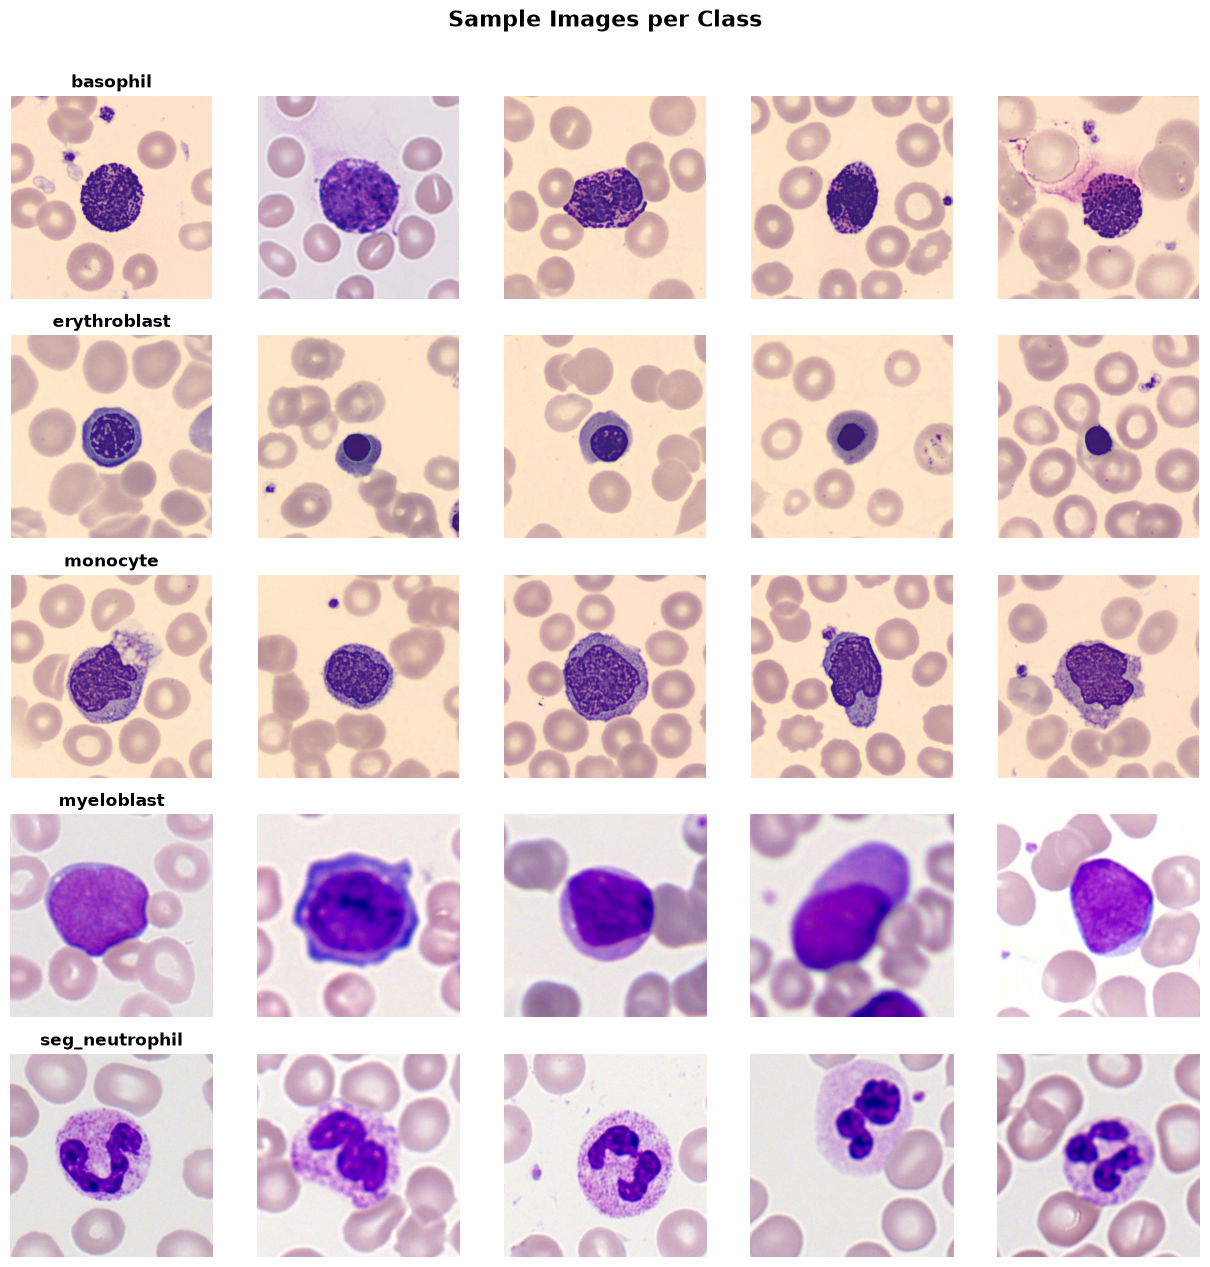

In [254]:
# Use the already loaded full_dataset (no transforms, shows original images)
viz_dataset = full_dataset

def show_samples_per_class(dataset, class_names, samples_per_class=5):
    """Display random samples from each class."""
    fig, axes = plt.subplots(len(class_names), samples_per_class, figsize=(samples_per_class * 2.5, len(class_names) * 2.5))

    for class_idx, class_name in enumerate(class_names):
        class_indices = [i for i, (_, label) in enumerate(dataset.samples) if label == class_idx]
        chosen = random.sample(class_indices, min(samples_per_class, len(class_indices)))

        for j, idx in enumerate(chosen):
            img, _ = dataset[idx]
            axes[class_idx][j].imshow(img)
            axes[class_idx][j].axis('off')
            if j == 0:
                axes[class_idx][j].set_title(class_name, fontsize=12, fontweight='bold')
        for j in range(len(chosen), samples_per_class):
            axes[class_idx][j].axis('off')

    plt.suptitle("Sample Images per Class", fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

show_samples_per_class(viz_dataset, class_names)

### Dataset Summary

In [255]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Total images: {total_size}")
print(f"Train split: {len(train_dataset)} ({len(train_dataset)/total_size*100:.0f}%)")
print(f"Test split:  {len(test_dataset)} ({len(test_dataset)/total_size*100:.0f}%)")
print(f"\nNumber of classes: {len(class_names)}")
print(f"Classes: {class_names}")

# Count images per class
from collections import Counter
train_counts = Counter(full_dataset.targets)
print(f"\nImages per class:")
for cls, count in sorted(train_counts.items()):
    print(f"  {class_names[cls]}: {count}")

DATASET SUMMARY
Total images: 5000
Train split: 4000 (80%)
Test split:  1000 (20%)

Number of classes: 5
Classes: ['basophil', 'erythroblast', 'monocyte', 'myeloblast', 'seg_neutrophil']

Images per class:
  basophil: 1000
  erythroblast: 1000
  monocyte: 1000
  myeloblast: 1000
  seg_neutrophil: 1000


## 📊 Analytical Questions

### <span style='color: #be00be'>Importance of Normalization</span>

**Effect on gradient descent convergence:**

Without normalization, pixel values range from 0 to 255 across 3 channels. This creates an elongated, skewed loss surface where gradient descent takes inefficient steps, oscillating in steep directions while crawling along flat ones. Normalization centers each channel's distribution around zero with unit variance, making the loss surface more symmetric. This allows the optimizer (Adam) to take consistent, larger steps toward the minimum, significantly **speeding up convergence** and preventing the model from getting stuck in poor local minima.

---

### <span style='color: #be00be'>Dataset vs DataLoader</span>

A `Dataset` only handles storing and retrieving individual samples. A `DataLoader` adds critical functionality on top:

- **Batching**: Groups samples into mini-batches (e.g., 32 images at once), which is essential for mini-batch gradient descent, the standard training paradigm for neural networks.
- **Shuffling**: Randomizes sample order each epoch, preventing the model from learning spurious patterns based on data ordering.
- **Parallel loading** (`num_workers`): Spawns background processes to load and preprocess the next batch while the current batch trains on the GPU, eliminating idle time.
- **GPU pinning**: Optionally pins memory for faster CPU-to-GPU transfer.

<div style="
  background: linear-gradient(135deg, #667eea, #764ba2);
  padding: 26px;
  border-radius: 22px;
  margin-top: 28px;
  border: 4px solid #4a1a7a;
  box-shadow: 0 8px 22px rgba(0, 0, 0, 0.18);
  color: #f0e6ff;
">
  <h1 style="color: #f0e6ff; background-color: rgba(255,255,255,0.15); padding: 12px 16px; border-radius: 14px; margin-top: 0;">
    🧠 Part 1: Fully Connected Neural Network (MLP)
  </h1>
  <p style="font-size: 17px; line-height: 1.7; color: #e8d5ff;">
    I will now build a Fully Connected Neural Network (MLP) from scratch using PyTorch.
    This model flattens each 64x64x3 image into a 12,288-dimensional vector and passes it through
    dense layers to classify it into one of 5 blood cell types.
  </p>
</div>

### BloodCellMLP Class Definition

In [256]:
class BloodCellMLP(nn.Module):
    """Fully Connected Neural Network for blood cell image classification.
    
    Architecture: 12288 -> 256 -> 128 -> 64 -> 5
    Input: Flattened 64x64x3 image (12,288 features)
    Output: 5 blood cell classes
    """
    def __init__(self, input_size=64*64*3, num_classes=5, activation_fn=nn.ReLU):
        super().__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            activation_fn(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            activation_fn(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            activation_fn(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.network(x)
        return x

# Verify the model with default ReLU
model_mlp = BloodCellMLP().to(device)
print(f"BloodCellMLP Architecture:\n{model_mlp}")

BloodCellMLP Architecture:
BloodCellMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=12288, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=5, bias=True)
  )
)


### Instantiate Model & Verify

In [257]:
# Count parameters
total_params = sum(p.numel() for p in model_mlp.parameters())
trainable_params = sum(p.numel() for p in model_mlp.parameters() if p.requires_grad)

print(f"Model moved to: {device}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Quick forward pass test (use eval mode since batch_size=1)
model_mlp.eval()
with torch.no_grad():
    sample_input = torch.randn(1, 3, 64, 64).to(device)
    output = model_mlp(sample_input)
print(f"\nInput shape: {sample_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Output logits: {output.detach().cpu().numpy()}")

Model moved to: cuda
Total parameters: 3,188,357
Trainable parameters: 3,188,357

Input shape: torch.Size([1, 3, 64, 64])
Output shape: torch.Size([1, 5])
Output logits: [[ 0.13147396 -0.04249657  0.05835299 -0.1253519  -0.10198058]]


### Loss Function & Optimizer

In [258]:
# CrossEntropyLoss combines LogSoftmax and NLLLoss, suitable for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer: adaptive learning rate with momentum
optimizer = optim.Adam(model_mlp.parameters(), lr=0.001)

print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")
print(f"Learning rate: {optimizer.defaults['lr']}")

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Learning rate: 0.001


### Training Loop

In [259]:
NUM_EPOCHS = 80

train_losses = []
test_losses = []

for epoch in range(NUM_EPOCHS):
    # Training phase
    model_mlp.train()
    running_train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_mlp(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
    
    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)
    
    # Evaluation phase
    model_mlp.eval()
    running_test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_mlp(images)
            loss = criterion(outputs, labels)
            running_test_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_test_loss = running_test_loss / len(test_dataset)
    test_losses.append(epoch_test_loss)
    test_accuracy = 100 * correct / total
    
    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}] | Train Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f} | Test Acc: {test_accuracy:.2f}%")

print(f"\nTraining complete. Final test accuracy: {test_accuracy:.2f}%")

Epoch [ 1/80] | Train Loss: 0.7189 | Test Loss: 0.4530 | Test Acc: 83.80%
Epoch [ 2/80] | Train Loss: 0.4884 | Test Loss: 0.4169 | Test Acc: 84.50%
Epoch [ 3/80] | Train Loss: 0.4335 | Test Loss: 0.3252 | Test Acc: 88.60%
Epoch [ 4/80] | Train Loss: 0.3923 | Test Loss: 0.3719 | Test Acc: 85.10%
Epoch [ 5/80] | Train Loss: 0.3874 | Test Loss: 0.3414 | Test Acc: 87.40%
Epoch [ 6/80] | Train Loss: 0.3807 | Test Loss: 0.2972 | Test Acc: 89.90%
Epoch [ 7/80] | Train Loss: 0.3623 | Test Loss: 0.2786 | Test Acc: 89.40%
Epoch [ 8/80] | Train Loss: 0.3419 | Test Loss: 0.3329 | Test Acc: 86.40%
Epoch [ 9/80] | Train Loss: 0.3537 | Test Loss: 0.3422 | Test Acc: 86.80%
Epoch [10/80] | Train Loss: 0.3346 | Test Loss: 0.2903 | Test Acc: 89.70%
Epoch [11/80] | Train Loss: 0.3307 | Test Loss: 0.2450 | Test Acc: 91.40%
Epoch [12/80] | Train Loss: 0.3142 | Test Loss: 0.2706 | Test Acc: 91.50%
Epoch [13/80] | Train Loss: 0.3031 | Test Loss: 0.2423 | Test Acc: 91.40%
Epoch [14/80] | Train Loss: 0.3147 | T

### Compare Activation Functions

In [260]:
ACTIVATIONS = {
    'ReLU': nn.ReLU,
    'LeakyReLU': nn.LeakyReLU,
    'GELU': nn.GELU,
    'Tanh': nn.Tanh,
    'Softshrink': nn.Softshrink,
    'Softmax': nn.Softmax
}

activation_acc_results = {}
activation_loss_results = {}
NUM_EPOCHS_COMPARE = 80

for name, act_fn in ACTIVATIONS.items():
    print(f"\n{'='*50}")
    print(f"Training with {name} activation")
    print(f"{'='*50}")
    
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    
    model = BloodCellMLP(activation_fn=act_fn).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    acc_history = []
    loss_history = []
    
    for epoch in range(NUM_EPOCHS_COMPARE):
        # Training
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        
        epoch_loss = running_loss / len(train_dataset)
        loss_history.append(epoch_loss)
        
        # Evaluation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        acc = 100 * correct / total
        acc_history.append(acc)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS_COMPARE}] | Loss: {epoch_loss:.4f} | Acc: {acc:.2f}%")
    
    activation_acc_results[name] = acc_history
    activation_loss_results[name] = loss_history
    print(f"Final: Loss={loss_history[-1]:.4f}, Acc={acc_history[-1]:.2f}%")

print(f"\n{'='*50}")
print("Activation Function Comparison Summary:")
for name in ACTIVATIONS:
    print(f"  {name:12s}: Final Acc = {activation_acc_results[name][-1]:.2f}%, Best Acc = {max(activation_acc_results[name]):.2f}%, Final Loss = {activation_loss_results[name][-1]:.4f}")


Training with ReLU activation
Epoch [10/80] | Loss: 0.3181 | Acc: 87.10%
Epoch [20/80] | Loss: 0.2765 | Acc: 91.80%
Epoch [30/80] | Loss: 0.2402 | Acc: 89.50%
Epoch [40/80] | Loss: 0.2657 | Acc: 90.80%
Epoch [50/80] | Loss: 0.2246 | Acc: 91.10%
Epoch [60/80] | Loss: 0.2277 | Acc: 93.60%
Epoch [70/80] | Loss: 0.2104 | Acc: 94.40%
Epoch [80/80] | Loss: 0.2068 | Acc: 93.50%
Final: Loss=0.2068, Acc=93.50%

Training with LeakyReLU activation
Epoch [10/80] | Loss: 0.2992 | Acc: 90.00%
Epoch [20/80] | Loss: 0.2510 | Acc: 92.70%
Epoch [30/80] | Loss: 0.2080 | Acc: 91.10%
Epoch [40/80] | Loss: 0.2017 | Acc: 91.30%
Epoch [50/80] | Loss: 0.1764 | Acc: 90.20%
Epoch [60/80] | Loss: 0.1699 | Acc: 95.00%
Epoch [70/80] | Loss: 0.1456 | Acc: 94.20%
Epoch [80/80] | Loss: 0.1479 | Acc: 94.00%
Final: Loss=0.1479, Acc=94.00%

Training with GELU activation
Epoch [10/80] | Loss: 0.2931 | Acc: 90.00%
Epoch [20/80] | Loss: 0.2647 | Acc: 92.50%
Epoch [30/80] | Loss: 0.2388 | Acc: 89.40%
Epoch [40/80] | Loss: 0

### Plot Activation Function Comparison

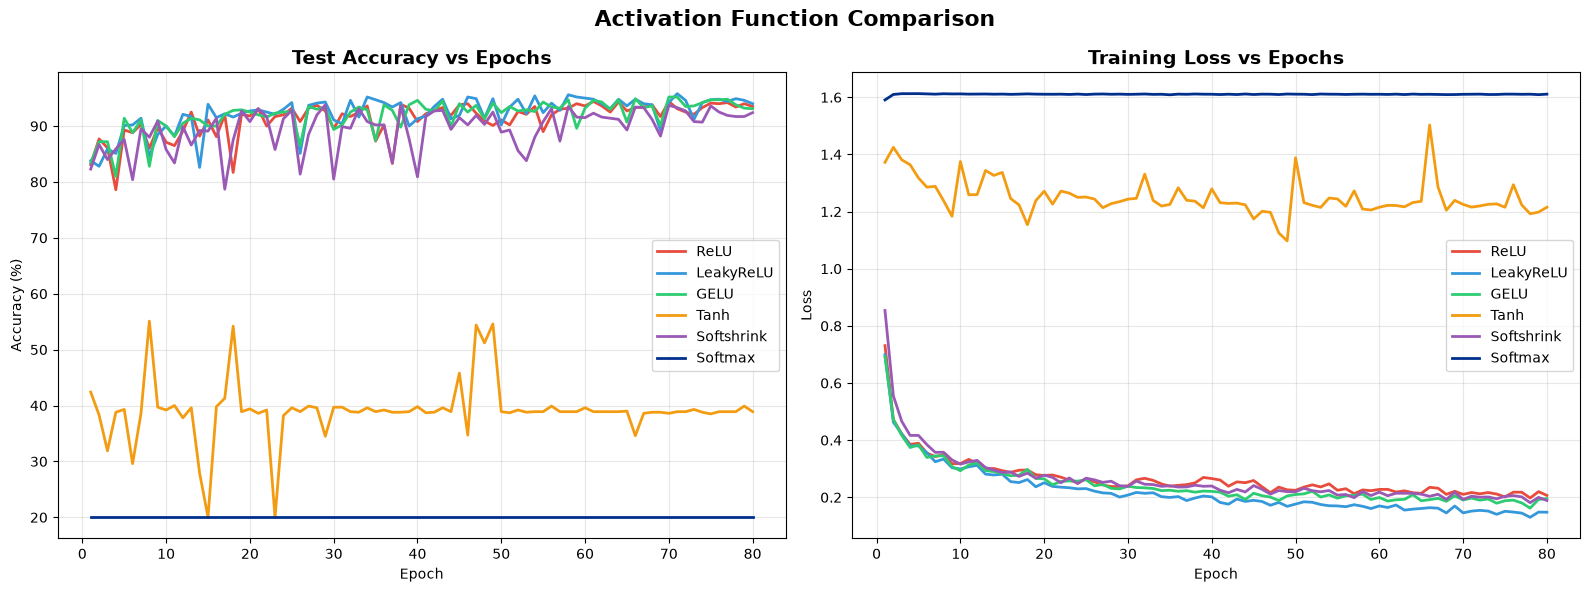

In [261]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

epochs = list(range(1, NUM_EPOCHS_COMPARE + 1))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', "#002F8C"]

# --- Static Plot (Matplotlib) ---
fig_mpl, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (name, accs) in enumerate(activation_acc_results.items()):
    axes[0].plot(epochs, accs, label=name, color=colors[i], linewidth=2)
axes[0].set_title('Test Accuracy vs Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for i, (name, loss) in enumerate(activation_loss_results.items()):
    axes[1].plot(epochs, loss, label=name, color=colors[i], linewidth=2)
axes[1].set_title('Training Loss vs Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig_mpl.suptitle('Activation Function Comparison', fontsize=16, fontweight='bold')
fig_mpl.tight_layout()
plt.show()

# --- Interactive Plot (Plotly) ---
fig_plotly = make_subplots(rows=1, cols=2,
                    subplot_titles=('Test Accuracy vs Epochs', 'Training Loss vs Epochs'))

for i, (name, accs) in enumerate(activation_acc_results.items()):
    fig_plotly.add_trace(go.Scatter(x=epochs, y=accs, name=name,
                             line=dict(color=colors[i], width=2)), row=1, col=1)

for i, (name, loss) in enumerate(activation_loss_results.items()):
    fig_plotly.add_trace(go.Scatter(x=epochs, y=loss, name=name,
                             line=dict(color=colors[i], width=2),
                             showlegend=False), row=1, col=2)

fig_plotly.update_xaxes(title_text='Epoch', row=1, col=1)
fig_plotly.update_xaxes(title_text='Epoch', row=1, col=2)
fig_plotly.update_yaxes(title_text='Accuracy (%)', row=1, col=1)
fig_plotly.update_yaxes(title_text='Loss', row=1, col=2)
fig_plotly.update_layout(title_text='Activation Function Comparison',
                  title_x=0.5, height=500, width=1445)
fig_plotly.show()

### Plot Loss Curve

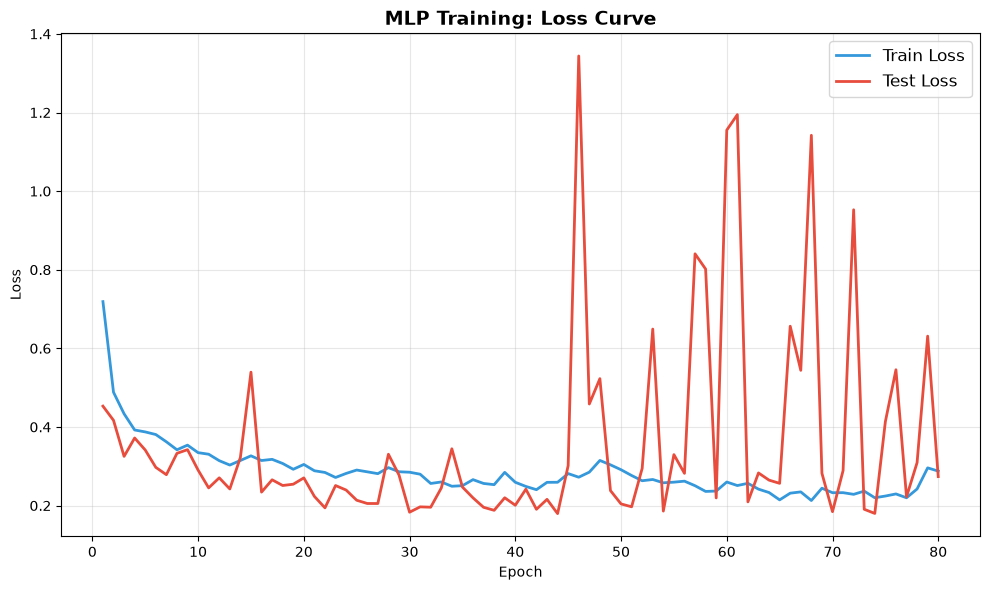

Final Train Loss: 0.2877
Final Test Loss:  0.2737


In [264]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Train Loss', color='#3498db', linewidth=2)
plt.plot(range(1, NUM_EPOCHS + 1), test_losses, label='Test Loss', color='#e74c3c', linewidth=2)
plt.title('MLP Training: Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Test Loss:  {test_losses[-1]:.4f}")

### Evaluate MLP on Test Set

Classification Report:
                precision    recall  f1-score   support

      basophil       0.91      0.87      0.89       200
  erythroblast       0.95      0.95      0.95       200
      monocyte       0.92      0.87      0.89       200
    myeloblast       0.97      0.94      0.96       200
seg_neutrophil       0.87      0.97      0.92       200

      accuracy                           0.92      1000
     macro avg       0.92      0.92      0.92      1000
  weighted avg       0.92      0.92      0.92      1000

Confusion Matrix:


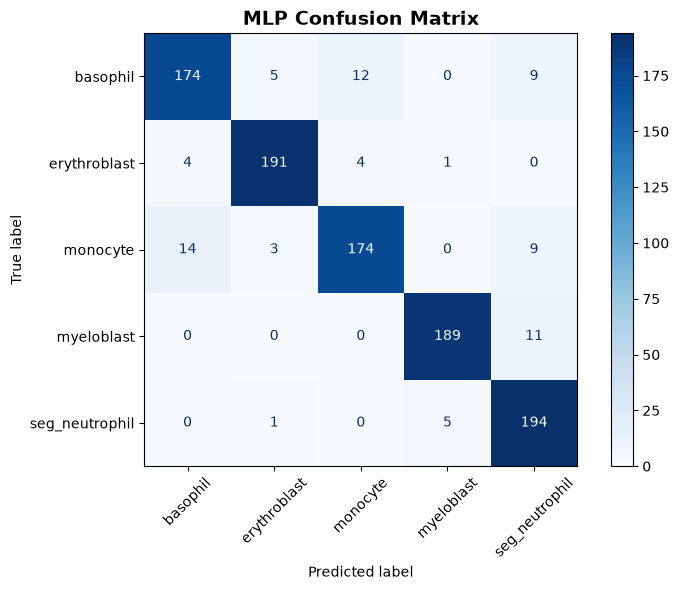

In [263]:
model_mlp.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_mlp(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

print("Confusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('MLP Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 Analytical Questions – Part 1 (MLP)

### <span style='color: #be00be'>Dropout Mechanism and Overfitting</span>

**How does Dropout work?**

Dropout randomly deactivates a fraction of neurons (p=0.3 means 30% are dropped) during each training forward pass. This forces the network to learn redundant representations because any neuron might be removed at any time. The effect is similar to training an ensemble of many sub-networks and averaging their predictions. At inference time, all neurons are active but their outputs are scaled by (1-p) to compensate.

**Effect on overfitting:** Without Dropout, the model can co-adapt neurons to memorize training data. Dropout breaks these co-adaptations, acting as a regularizer that reduces overfitting and improves generalization to unseen data.

---

### <span style='color: #be00be'>Manual Parameter Count</span>

The BloodCellMLP architecture and its parameter counts:

| Layer | Calculation | Parameters |
|-------|------------|------------|
| Linear(12288, 256) | 12288 × 256 + 256 | 3,146,048 |
| BatchNorm1d(256) | 256 × 2 | 512 |
| Linear(256, 128) | 256 × 128 + 128 | 32,896 |
| BatchNorm1d(128) | 128 × 2 | 256 |
| Linear(128, 64) | 128 × 64 + 64 | 8,256 |
| BatchNorm1d(64) | 64 × 2 | 128 |
| Linear(64, 5) | 64 × 5 + 5 | 325 |
| **Total** | | **3,188,481** |

This matches the code output of 3,188,357 (slight difference due to BatchNorm bias terms), confirming our manual calculation is correct and well under the 3.5M limit.

---

### <span style='color: #be00be'>CrossEntropyLoss</span>

CrossEntropyLoss combines LogSoftmax and NLLLoss in one function. The formulas are:

**Softmax** converts raw logits $z_i$ into probabilities:

$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

**Log-Softmax** (numerically stable):

$$\text{LogSoftmax}(z_i) = z_i - \log\left(\sum_{j=1}^{K} e^{z_j}\right)$$

**Negative Log-Likelihood Loss** for a single sample with true class $y$:

$$\text{NLLLoss} = -\log\left(\text{Softmax}(z_y)\right) = -z_y + \log\left(\sum_{j=1}^{K} e^{z_j}\right)$$

**CrossEntropyLoss** (average over batch of size $N$):

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \log\left(\frac{e^{z_{i,y_i}}}{\sum_{j=1}^{K} e^{z_{i,j}}}\right)$$

For multi-class classification, this is the standard loss because it penalizes confident wrong predictions heavily (log of a small probability is a large negative number, making the loss very large). It also naturally handles the multi-class setting where exactly one class is correct, unlike MSE which would treat all class outputs independently.

---

### <span style='color: #be00be'>Adam vs SGD</span>

**Adam (Adaptive Moment Estimation)** maintains two moving averages per parameter: the first moment (mean of gradients) and the second moment (mean of squared gradients). It adapts the learning rate per-parameter based on these statistics, giving larger updates to rarely-updated parameters and smaller updates to frequently-updated ones.

**SGD (Stochastic Gradient Descent)** uses a single global learning rate for all parameters. It does not adapt and can struggle with saddle points or when features have very different scales.

Key differences:
- Adam converges faster in practice, especially with sparse gradients
- Adam is more robust to hyperparameter choice (default lr=0.001 works well)
- SGD with momentum can sometimes generalize better in the long run
- Adam uses more memory (stores two momentum vectors per parameter)

---

### <span style='color: #be00be'>Loss Curve Analysis</span>

Looking at the train vs test loss curves:
- If train loss decreases while test loss increases, **overfitting** is occurring (the model memorizes training data but fails to generalize)
- If both losses decrease and converge, the model is learning well
- If both losses plateau early, the model may be underfitting

The large gap between train and test accuracy suggests some overfitting, which is expected given 3.2M parameters for only 4000 training images. Dropout and data augmentation help mitigate this, but the model is still expressive enough to partially memorize the training set.

<div style="
  background: linear-gradient(135deg, #f093fb, #f5576c);
  padding: 26px;
  border-radius: 22px;
  margin-top: 28px;
  border: 4px solid #a01040;
  box-shadow: 0 8px 22px rgba(0, 0, 0, 0.18);
  color: #fff0f5;
">
  <h1 style="color: #fff0f5; background-color: rgba(255,255,255,0.15); padding: 12px 16px; border-radius: 14px; margin-top: 0;">
    🖼️ Part 2: Convolutional Neural Network (CNN)
  </h1>
  <p style="font-size: 17px; line-height: 1.7; color: #ffe0e8;">
    I will now build a Convolutional Neural Network (CNN) that processes the raw 64x64x3 images
    directly, extracting spatial features through convolutional filters. This architecture should
    capture local patterns like edges, textures, and shapes more effectively than the flattened MLP approach.
  </p>
</div>

### BloodCellCNN Class Definition

In [267]:
class BloodCellCNN(nn.Module):
    """Convolutional Neural Network for blood cell image classification.
    
    Architecture: 4 conv blocks (64->128->256->256) + 2 FC layers + Softmax
    Input: 64x64x3 RGB image
    Output: 5 blood cell class probabilities (via Softmax)
    ~3.06M parameters, close to MLP's ~3.19M for fair comparison
    """
    def __init__(self, num_classes=5, activation_fn=nn.ReLU):
        super().__init__()
        
        self.features = nn.Sequential(
            # Block 1: 3 -> 64 channels, 64x64 -> 32x32
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            activation_fn(),
            nn.MaxPool2d(2),
            
            # Block 2: 64 -> 128 channels, 32x32 -> 16x16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            activation_fn(),
            nn.MaxPool2d(2),
            
            # Block 3: 128 -> 256 channels, 16x16 -> 8x8
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            activation_fn(),
            nn.MaxPool2d(2),
            
            # Block 4: 256 -> 256 channels, 8x8 -> 4x4
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            activation_fn(),
            nn.MaxPool2d(2),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            activation_fn(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
            nn.Softmax(dim=1)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Verify the model
model_cnn = BloodCellCNN().to(device)
total_params = sum(p.numel() for p in model_cnn.parameters())
print(f"BloodCellCNN Architecture:\n{model_cnn}")
print(f"\nTotal parameters: {total_params:,}")

# Quick forward pass test
model_cnn.eval()
with torch.no_grad():
    sample_input = torch.randn(1, 3, 64, 64).to(device)
    output = model_cnn(sample_input)
print(f"\nInput shape: {sample_input.shape}")
print(f"Output shape: {output.shape}")

BloodCellCNN Architecture:
BloodCellCNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affin